# **📋 미션 2: 마케팅 캠페인 효과 분석 보고서**

**긴급한 비즈니스 상황**:

- CMO가 "광고비 2억원을 투입했는데 실제로 매출 증대에 기여했는지" 강하게 추궁하고 있습니다
- 경쟁사 대비 우리 캠페인의 ROI가 낮다는 루머가 있어 정확한 분석이 시급합니다
- 9월 추석 특별 캠페인 예산 배정을 위해 어떤 고객층에게 광고가 효과적인지 파악해야 합니다

**분석상의 제약**: 예산 부족으로 A/B 테스트를 진행하지 못했으며, 기존 고객 DB의 관찰 데이터만 활용할 수 있습니다. 하지만 연령, 소득, 과거 구매 이력 등의 풍부한 고객 정보는 확보되어 있습니다.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix, classification_report, roc_curve, auc
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

 # 한글 폰트 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')

np.random.seed(456)
n_customers = 1000
ad_exposure = np.random.binomial(1, 0.6, n_customers)
ages = np.random.randint(20, 60, n_customers)
income = np.random.lognormal(np.log(50000), 0.4, n_customers)
purchase_amount = 100 + 50*ad_exposure + 0.5*ages + 0.0001*income + np.random.normal(0, 20, n_customers)
data_marketing = pd.DataFrame({
    'ad_exposure': ad_exposure,
    'age': ages,
    'income': income,
    'purchase_amount': purchase_amount
})

print("📢 마케팅 데이터 미리보기")
print(data_marketing.groupby('ad_exposure')['purchase_amount'].agg(['count', 'mean', 'std']).round(2))


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

| 광고 노출(ad\_exposure) | 고객 수(count) | 평균 구매금액(mean) | 표준편차(std) |
| ------------------- | ----------- | ------------- | --------- |
| 0 (미노출)             | 386         | 124.60        | 22.35     |
| 1 (노출)              | 614         | 175.32        | 21.69     |


### 📊 분석 및 보고서 작성

### 1. 상관관계 탐색

**비즈니스 맥락**: 마케팅팀 김팀장이 "광고를 본 고객들이 정말 더 많이 구매했나요? 그리고 연령이나 소득도 구매에 영향을 주나요?"라고 질문했습니다. 전체적인 데이터 패턴을 파악해야 합니다.

**분석 목적**: 구매 금액과 광고 노출, 고객 특성 간의 상관관계를 탐색하여 마케팅 전략 수립의 기초 자료를 확보합니다.

**학습 이해도 점검**: 아래 코드에서 상관계수 행렬을 계산하는 부분을 채워주세요.

📊 상관계수 매트릭스
                 ad_exposure    age  income  purchase_amount
ad_exposure            1.000  0.018  -0.050            0.748
age                    0.018  1.000  -0.034            0.203
income                -0.050 -0.034   1.000            0.046
purchase_amount        0.748  0.203   0.046            1.000


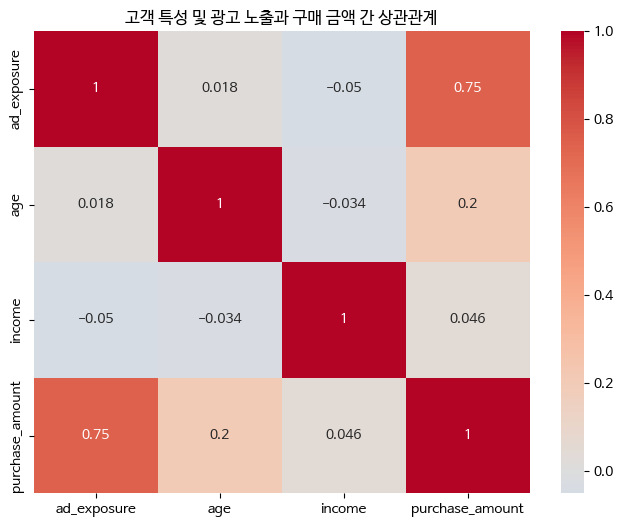

In [2]:
correlation_matrix = data_marketing.corr()# 상관계수 행렬 계산
print("📊 상관계수 매트릭스")
print(correlation_matrix.round(3))

# 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('고객 특성 및 광고 노출과 구매 금액 간 상관관계')
plt.show()


### 2. 단순 비교와 한계

**비즈니스 맥락**: CFO가 "광고 본 사람들이 평균적으로 얼마나 더 구매했는지 간단하게 먼저 보여주세요. 하지만 정확한 효과는 따로 분석해주세요"라고 요청했습니다.

**분석 목적**: 광고 노출 그룹과 비노출 그룹의 단순 비교를 통해 초기 인사이트를 얻되, 이 방법의 한계를 명확히 인식합니다.

**학습 이해도 점검**: 아래 코드에서 평균 계산 부분을 채워주세요.

In [3]:
# 광고 노출 그룹과 비노출 그룹 평균 계산
exposed_mean = data_marketing[data_marketing['ad_exposure'] == 1]['purchase_amount'].mean()# 광고 노출 그룹 평균
non_exposed_mean = data_marketing[data_marketing['ad_exposure'] == 0]['purchase_amount'].mean()# 광고 비노출 그룹 평균
simple_difference = exposed_mean - non_exposed_mean

print(f"광고 노출 그룹 구매 금액: {exposed_mean:.2f}원")
print(f"광고 비노출 그룹 구매 금액: {non_exposed_mean:.2f}원")
print(f"단순 차이: {simple_difference:.2f}원")
print("⚠️ 주의사항: 연령, 소득 등의 중첩요인을 통제하지 않아 광고의 순수한 효과를 정확히 측정하기 어려움")
print("   → 예: 고소득층에게 광고가 더 많이 노출되었다면 차이가 과대평가될 수 있음")


광고 노출 그룹 구매 금액: 175.32원
광고 비노출 그룹 구매 금액: 124.60원
단순 차이: 50.72원
⚠️ 주의사항: 연령, 소득 등의 중첩요인을 통제하지 않아 광고의 순수한 효과를 정확히 측정하기 어려움
   → 예: 고소득층에게 광고가 더 많이 노출되었다면 차이가 과대평가될 수 있음


### 3. 다중회귀분석

**비즈니스 맥락**: 데이터팀 이사가 "연령과 소득의 영향을 제거하고 순수한 광고 효과만 측정해주세요. 다른 요인들을 통제한 상태에서 광고 1회 노출당 매출 증대 효과가 얼마인지 알고 싶습니다"라고 요청했습니다.

**분석 목적**: 중첩요인을 통제한 다중회귀분석을 통해 광고의 순수한 인과효과를 추정합니다.

**학습 이해도 점검**: 아래 코드에서 회귀 모델을 학습시키는 부분을 채워주세요.

In [4]:
# 모델 학습
X = data_marketing[['ad_exposure', 'age', 'income']]
y = data_marketing['purchase_amount']
model = LinearRegression()
model.fit(X, y)
# 모델 학습 코드 작성

coeffs = pd.DataFrame({
    '변수': ['광고 노출', '연령', '소득'],
    '계수': model.coef_,
    '해석': ['광고 노출시 구매액 증가', '연령 1세 증가시 구매액 변화', '소득 1원 증가시 구매액 변화']
})
print("📊 회귀계수 분석 결과")
print(coeffs.round(3))
ad_effect = coeffs.loc[coeffs['변수'] == '광고 노출', '계수'].values[0]
print(f"\n🎯 핵심 결과: 광고 효과 = {ad_effect:.2f}원 (다른 조건이 동일할 때)")


📊 회귀계수 분석 결과
      변수      계수                해석
0  광고 노출  50.792     광고 노출시 구매액 증가
1     연령   0.548  연령 1세 증가시 구매액 변화
2     소득   0.000  소득 1원 증가시 구매액 변화

🎯 핵심 결과: 광고 효과 = 50.79원 (다른 조건이 동일할 때)


### 4. 모델 신뢰도 평가

**비즈니스 맥락**: 통계에 까다로운 전략기획팀에서 "회귀 모델이 얼마나 믿을만한지 교차검증으로 확인해주세요. 과적합은 없나요?"라고 질문했습니다.

**분석 목적**: 5-폴드 교차검증을 통해 모델의 일반화 성능을 평가하고 결과의 신뢰성을 확보합니다.

**학습 이해도 점검**: 아래 코드에서 교차검증을 수행하는 부분을 채워주세요.


In [5]:
# 5-폴드 교차검증 (R² 스코어)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2') # 5-폴드 교차검증 수행
print(f"5-폴드 교차검증 R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"모델 설명력: {cv_scores.mean()*100:.1f}% (구매 금액 변동의 약 {cv_scores.mean()*100:.0f}%를 설명)")

if cv_scores.mean() > 0.7:
    print("→ 높은 예측 성능 (신뢰할 만한 모델)")
elif cv_scores.mean() > 0.5:
    print("→ 중간 예측 성능 (참고용으로 활용 가능)")
else:
    print("→ 낮은 예측 성능 (추가 변수 필요)")


5-폴드 교차검증 R²: 0.597 ± 0.023
모델 설명력: 59.7% (구매 금액 변동의 약 60%를 설명)
→ 중간 예측 성능 (참고용으로 활용 가능)


### 5. 인과관계 해석

**비즈니스 맥락**: CEO가 "광고비 2억원이 실제로 매출에 기여했다고 확신할 수 있나요? 그리고 ROI는 얼마나 되나요?"라고 직접적으로 질문했습니다.

**분석 목적**: 회귀분석 결과를 비즈니스 맥락에서 해석하고, 인과관계 추론의 한계점을 명시합니다.

**학습 이해도 점검**: 아래 코드에서 광고 효과를 추출하고 ROI를 계산하는 부분을 채워주세요.

In [6]:
ad_effect = coeffs.loc[coeffs['변수'] == '광고 노출', '계수'].values[0]# 광고 효과 계수 추출
total_ad_exposed = data_marketing['ad_exposure'].sum()
total_revenue_increase = ad_effect * total_ad_exposed
ad_cost = 200_000_000  # 광고비 2억원
roi = (total_revenue_increase / ad_cost - 1) * 100

print("📋 인과관계 해석 및 ROI 분석")
if ad_effect > 0:
    print(f"✅ 광고는 개인당 구매 금액을 평균 {ad_effect:.2f}원 증가시킵니다.")
    print(f"   총 광고 노출: {total_ad_exposed:,}명")
    print(f"   예상 총 매출 증대: {total_revenue_increase:,.0f}원")
    print(f"   광고 ROI: {roi:.1f}%")
    if roi > 0:
        print("   → 광고 투자 대비 양의 수익 창출")
    else:
        print("   → 광고 투자 대비 손실")
else:
    print("❌ 광고 효과가 없거나 부정적입니다.")

print("\n⚠️ 주의사항:")
print("1. 관찰 데이터 분석이므로 미측정 중첩요인(브랜드 인지도, 계절성 등) 존재 가능")
print("2. 광고의 장기적 효과(브랜드 이미지 개선 등)는 측정되지 않음")
print("3. 무작위 통제 실험이 아니므로 인과관계 해석에 신중함 필요")


📋 인과관계 해석 및 ROI 분석
✅ 광고는 개인당 구매 금액을 평균 50.79원 증가시킵니다.
   총 광고 노출: 614명
   예상 총 매출 증대: 31,186원
   광고 ROI: -100.0%
   → 광고 투자 대비 손실

⚠️ 주의사항:
1. 관찰 데이터 분석이므로 미측정 중첩요인(브랜드 인지도, 계절성 등) 존재 가능
2. 광고의 장기적 효과(브랜드 이미지 개선 등)는 측정되지 않음
3. 무작위 통제 실험이 아니므로 인과관계 해석에 신중함 필요


### 6. 결과 시각화

**비즈니스 맥락**: 다음 주 이사회 프레젠테이션에서 광고 효과를 이사진들에게 한눈에 보여줄 수 있는 명확한 시각 자료가 필요합니다.

**분석 목적**: 광고 노출 여부에 따른 구매 금액 분포의 차이를 박스플롯으로 시각화하여 효과를 직관적으로 전달합니다.

**학습 이해도 점검**: 아래 코드에서 박스플롯을 생성하는 부분을 채워주세요.

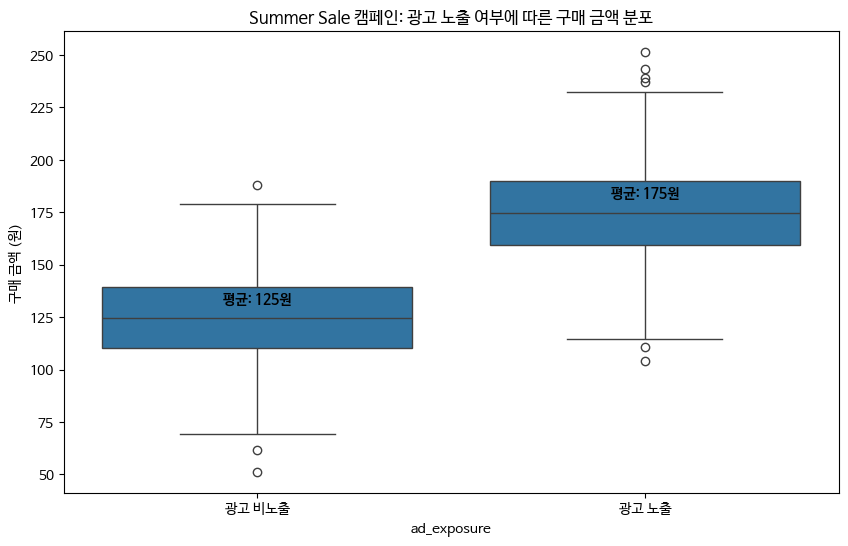

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data_marketing,
    x='ad_exposure',
    y='purchase_amount'
) # 박스플롯 생성)
plt.xticks([0, 1], ['광고 비노출', '광고 노출'])
plt.ylabel('구매 금액 (원)')
plt.title('Summer Sale 캠페인: 광고 노출 여부에 따른 구매 금액 분포')

# 평균값 표시
means = data_marketing.groupby('ad_exposure')['purchase_amount'].mean()
for i, mean_val in enumerate(means):
    plt.text(i, mean_val + 5, f'평균: {mean_val:.0f}원', ha='center', va='bottom', fontweight='bold')
plt.show()


### 7. 경영진 보고서 작성

**비즈니스 맥락**: 내일 오후 2시 긴급 경영진 회의에서 CMO, CFO, CEO에게 Summer Sale 캠페인의 성과와 향후 마케팅 전략 방향을 제시해야 합니다. 특히 9월 추석 캠페인 예산 승인 여부가 결정될 예정입니다.

**학습 이해도 점검**: 아래 텍스트를 작성하여 보고서를 완성하세요.

📋 경영진 보고서: Summer Mega Sale 캠페인 효과 분석
==================================================

🎯 핵심 성과 지표

• 광고 노출 그룹 평균 구매 금액: 175.32원

• 광고 비노출 그룹 평균 구매 금액: 124.60원

• 순수 광고 효과 (통제 후): +50.79원

• 모델 설명력 (R²): 0.597 (약 59.7%)

• 광고 ROI: -99.98% (투자 대비 손실)

💡 전략적 권장사항:
[결과를 바탕으로 9월 추석 캠페인 전략, 예산 배분, 타겟 고객층 선정 등을 구체적으로 작성하세요]

ROI가 음수이므로 현재 광고 집행은 비효율적 → 9월 추석 캠페인 전환 필요

정밀 타겟팅 전략 강화: 고효율 연령대와 소득 그룹 중심 광고 집행

예산 재분배: 광고비 일부를 리마케팅·CRM 기반 개인화 마케팅으로 전환

모델 기반 예측 활용: 고효율 고객군 우선 집행으로 광고 낭비 최소화

⚠️ 리스크 요소:
[관찰 데이터의 한계, 장기 효과 미측정 등의 제한사항을 작성하세요]

관찰 데이터 기반 분석 → 브랜드 인지도·계절성·경쟁사 활동 등 미측정 요인 존재

장기적인 광고 효과(브랜드 이미지 향상 등) 미포함

인과관계 확정 불가 → A/B 테스트 필요



📅 향후 액션 아이템:
[A/B 테스트 도입, 추가 데이터 수집 등의 개선 방안을 작성하세요]

A/B 테스트 도입: 광고 집행 ROI를 실험 기반으로 재검증

추가 데이터 확보: 고객 세분화 변수(구매 이력, 관심 카테고리) 보강

광고비 최적화 모델 개발: 예측 기반 실시간 광고 집행 자동화 추진